# ECMWF TC Tracks, Wind & Gust Pipeline

This notebook demonstrates the TC track, wind, and gust processing pipeline: from BUFR download through to ensemble wind and gust threshold envelopes.

For precipitation, see `pipeline_demonstration_precipitation.ipynb`.

## Overview

| Step | Module | Output |
|---|---|---|
| 1. Download TC Data | `ecmwf_tc_data_downloader` | Single BUFR4 per run (all storms, all members) |
| 2. Extract BUFR | `ecmwf_tc_data_extractor` | Per-storm CSVs (one file per named storm) |
| 3. Transform | `ecmwf_tc_data_transformer` | Standardised tracks with wind radii + WKT polygons |
| 4. Download Wind | `ecmwf_wind_data_downloader` | Ensemble 10m wind GRIB files (`type="pf"/"cf"`) |
| 4b. Download Gust | `ecmwf_wind_data_downloader` | Ensemble 10fg gust GRIB files (6–144h, steps ≤ 90h → `10fg`, > 90h → `10fg3`) |
| 5. Wind Combination | `ecmwf_tc_wind_combination` | Wind threshold contours, unioned across forecast steps |
| 5b. Gust Envelopes | `ecmwf_gust_envelope_extractor` | Gust threshold contours (m/s), unioned across forecast steps |

| Output file | Snowflake table | Contents |
|---|---|---|
| `*_transformed.csv` | `TC_TRACKS` | One row per member × step, with wind radii and polygons |
| `*_envelopes_individual.csv` | `TC_ENVELOPES_INDIVIDUAL` | Wind threshold polygon per member × step |
| `*_envelopes_combined.csv` | `TC_ENVELOPES_COMBINED` | Unioned wind polygon per member × threshold |
| `*_gust_envelopes_individual.csv` | `TC_GUST_ENVELOPES_INDIVIDUAL` | Gust threshold polygon (m/s) per member × step |
| `*_gust_envelopes_combined.csv` | `TC_GUST_ENVELOPES_COMBINED` | Unioned gust polygon per member × threshold |

## Setup


In [1]:
import os
import pandas as pd
from pathlib import Path

# Pipeline modules
from ecmwf_tc_data_downloader import download_tc_data, list_downloaded_files
from ecmwf_tc_data_extractor import extract_tc_data, filter_tc_data, save_per_storm_csvs
from ecmwf_tc_data_transformer import transform_tc_data_from_file
from ecmwf_wind_data_downloader import download_ensemble_wind, download_ensemble_gust
from ecmwf_tc_wind_combination import process_wind_combination
from ecmwf_gust_envelope_extractor import process_gust_combination

In [2]:
# ── Date / run-time selection ──────────────────────────────────────────────
#
# ECMWF publishes four TC track forecast runs per day:
#   00Z  (published ~09:00 UTC)  →  240-hour track horizon
#   06Z  (published ~13:00 UTC)  →  144-hour track horizon
#   12Z  (published ~21:00 UTC)  →  240-hour track horizon
#   18Z  (published ~01:00 UTC)  →  144-hour track horizon
#
# Leave SELECTED_DATE empty ("") to download the most recent available run.

SELECTED_DATE    = ""           # "YYYYMMDD" or "" for latest
SELECTED_RUNTIME = ""         # "00" / "06" / "12" / "18", or "" for latest

if SELECTED_DATE:
    print(f"Target: {SELECTED_DATE} {SELECTED_RUNTIME or 'any'}Z")
else:
    print("Target: latest available forecast (determined by ecmwf-opendata client)")

Target: latest available forecast (determined by ecmwf-opendata client)


In [ ]:
# Example override: uncomment and set to target a specific run:
# SELECTED_DATE    = "20251109"
# SELECTED_RUNTIME = "00"

In [4]:
# Create output directories
directories = {
    'tc_data':        'tc_data',          # downloaded BUFR files + extracted per-storm CSVs
    'tc_transformed': 'tc_transformed',   # transformed TC CSVs
    'wind_data':      'wind_data',        # wind GRIB files
    'wind_extracted': 'wind_extracted',   # wind envelope CSVs
}

for dir_path in directories.values():
    Path(dir_path).mkdir(exist_ok=True)

## Step 1: Download TC Data


In [ ]:
# Download TC data: returns a single combined BUFR4 file per forecast run
# (all active storms × all 51 ensemble members in one file)
result = download_tc_data(
    date=SELECTED_DATE,
    run_time=SELECTED_RUNTIME,
    output_dir=directories['tc_data'],
)
print(f"Downloaded: {result['downloaded']}  Failed: {result['failed']}")

bufr_files = list(Path(directories['tc_data']).glob("*.bufr4"))
print(f"BUFR files: {[f.name for f in bufr_files]}")

## Step 2: Extract BUFR Data


In [6]:
# Extract all storms from the combined BUFR file,
# filter to named storms, and write one CSV per storm.
per_storm_csvs = []

for bufr_file in bufr_files:
    print(f"Extracting: {bufr_file.name}")
    df = extract_tc_data(str(bufr_file), verbose=False)

    if df.empty:
        print("  No data extracted")
        continue

    df = filter_tc_data(df, named_storms_only=True)
    if df.empty:
        print("  No named storms found")
        continue

    storms = df['storm_id'].unique()
    print(f"  Named storms: {list(storms)}")

    csv_paths = save_per_storm_csvs(df, directories['tc_data'], bufr_file.name, verbose=True)
    per_storm_csvs.extend(csv_paths)

print(f"\nPer-storm CSVs written: {len(per_storm_csvs)}")
for p in per_storm_csvs:
    print(f"  {p}")

Extracting: tc_tracks_2026-07-02_r06.bufr4
Number of Ensemble Members:  51
Number of Ensemble Members:  51
Number of Ensemble Members:  51
Number of Ensemble Members:  51
Number of Ensemble Members:  51
Number of Ensemble Members:  31
Number of Ensemble Members:  9
Number of Ensemble Members:  2
Number of Ensemble Members:  51
Number of Ensemble Members:  47
Number of Ensemble Members:  25
Number of Ensemble Members:  9
Number of Ensemble Members:  3
Number of Ensemble Members:  1
Number of Ensemble Members:  25
Number of Ensemble Members:  14
Number of Ensemble Members:  4
Number of Ensemble Members:  1
Number of Ensemble Members:  30
Number of Ensemble Members:  13
Number of Ensemble Members:  3
Number of Ensemble Members:  13
Number of Ensemble Members:  15
Number of Ensemble Members:  2
Number of Ensemble Members:  28
Number of Ensemble Members:  3
Number of Ensemble Members:  23
Number of Ensemble Members:  7
Number of Ensemble Members:  3
Number of Ensemble Members:  51
Number of

In [7]:
# ── Storm selection ────────────────────────────────────────────────────────
# Available storms were printed above. Set SELECTED_STORM to one of them,
# or leave empty ("") to use the first available storm.

SELECTED_STORM = "BAVI"     # e.g. "MAILA", "VAIANU", "INDUSA", or "" for first

# Resolve storm name and filter all downstream processing to that storm only
_available_storms = sorted({
    Path(p).name.split('_storm_')[1].split('_')[0]
    for p in per_storm_csvs
    if '_storm_' in Path(p).name
})

if not _available_storms:
    raise RuntimeError(
        "No storm CSVs found -- the download likely failed (404 for an old date). "
        "Update SELECTED_DATE in the Setup cell to a date within the last ~30 days "
        "when an active named storm was present."
    )

_storm = SELECTED_STORM.strip().upper() if SELECTED_STORM.strip() else _available_storms[0]
if _storm not in _available_storms:
    print(f"WARNING: '{_storm}' not found in {_available_storms}, defaulting to '{_available_storms[0]}'")
    _storm = _available_storms[0]

# Filter per_storm_csvs so Steps 3–5 only run for the selected storm
per_storm_csvs = [p for p in per_storm_csvs if f'_storm_{_storm}_' in Path(p).name]

# Dedicated subdirectories for the selected storm (keeps Step 5 isolated)
_storm_tc_dir      = Path(directories['tc_transformed']) / _storm
_storm_env_dir     = Path(directories['wind_extracted'])  / _storm
_storm_tc_dir.mkdir(exist_ok=True)
_storm_env_dir.mkdir(exist_ok=True)

print(f"Selected storm : {_storm}")
print(f"CSV to process : {[Path(p).name for p in per_storm_csvs]}")
print(f"Transform dir  : {_storm_tc_dir}")
print(f"Envelope dir   : {_storm_env_dir}")

Selected storm : BAVI
CSV to process : ['tc_tracks_2026-07-02_r06_storm_BAVI_extracted.csv']
Transform dir  : tc_transformed/BAVI
Envelope dir   : wind_extracted/BAVI


## Step 3: Transform Data


In [8]:
# Transform the selected storm's CSV into Snowflake-ready format
# (standardised units, wind radii, WKT polygons)
transformation_results = []

for csv_path in per_storm_csvs:
    csv_file = Path(csv_path)
    result = transform_tc_data_from_file(
        filename=str(csv_file),
        output_dir=str(_storm_tc_dir),
        verbose=True,
    )
    if result['success']:
        transformation_results.append(result)
        print(f"  {result['records']} records → {Path(result['csv_file']).name}")
    else:
        print(f"  Failed: {csv_file.name}")

transformed_files = [Path(r['csv_file']) for r in transformation_results]
print(f"\nTransformed files: {[f.name for f in transformed_files]}")

Transforming tropical cyclone data from: tc_data/tc_tracks_2026-07-02_r06_storm_BAVI_extracted.csv
Transforming: tc_data/tc_tracks_2026-07-02_r06_storm_BAVI_extracted.csv
  Loaded 15300 rows
 Validation passed: 15300 rows, 15 columns
  Forecast issued at: 2026-07-02 06:00:00
  Found 1275 unique forecast points
  Converting 15150 wind radii records to wide format
  Converted pressure from Pa to hPa
  Converted wind speed from m/s to knots
  Calculating radius of maximum winds
  Creating wind field polygons for 34 kt winds
  Creating wind field polygons for 50 kt winds
  Creating wind field polygons for 64 kt winds
  Converting polygons to WKT format
  Saved 1275 forecast records to tc_transformed/BAVI/tc_tracks_2026-07-02_r06_storm_BAVI_extracted_transformed.csv

  Transformation Summary:
    Input rows:  15300
    Output rows: 1275 (deduplication: 14025 rows removed)
    Storms: 1
    Ensemble members: 51
    Time steps: 25
    Date range: 2026-07-02 06:00:00 to 2026-07-08 06:00:00
Sum

## Step 4: Download Wind Data


In [9]:
# Download wind forecast data for the same run as the TC data.
# forecast_hours controls how many lead times to fetch (every 6h, 0→144h = full range).
# Reduce the list here to speed up the notebook demo, e.g. list(range(0, 25, 6)).
forecast_hours = list(range(0, 145, 6))  # full range: 0, 6, 12, … 144h

if SELECTED_DATE:
    wind_date     = f"{SELECTED_DATE[:4]}-{SELECTED_DATE[4:6]}-{SELECTED_DATE[6:]}"
    wind_run_time = int(SELECTED_RUNTIME)
else:
    # If using latest TC data, derive date/run from the downloaded BUFR filename
    import re
    bufr_name  = bufr_files[0].stem          # e.g. "tc_tracks_2026-04-06_r06"
    wind_date  = re.search(r'(\d{4}-\d{2}-\d{2})', bufr_name).group(1)
    wind_run_time = int(re.search(r'_r(\d{2})', bufr_name).group(1))
    print(f"Derived from filename: date={wind_date}  run={wind_run_time:02d}Z")

wind_files = download_ensemble_wind(
    date=wind_date,
    run_time=wind_run_time,
    forecast_hours=forecast_hours,
    output_dir=directories['wind_data'],
)

Derived from filename: date=2026-07-02  run=06Z
ECMWF ENSEMBLE WIND FORECAST DOWNLOAD (CONCURRENT)
Date: 2026-07-02
Run: 06Z
Forecast hours: 25 steps (0-144h)
Concurrent workers: 4
Output: wind_data/
  [SKIP] +  0h CF: Already exists (1.6 MB)
  [SKIP] +  0h PF: Already exists (50.1 MB)
  [SKIP] +  6h PF: Already exists (51.0 MB)
  [SKIP] +  6h CF: Already exists (1.7 MB)
  [SKIP] + 12h CF: Already exists (1.7 MB)
  [SKIP] + 18h PF: Already exists (34.3 MB)
  [SKIP] + 12h PF: Already exists (43.6 MB)
  [SKIP] + 24h CF: Already exists (1.7 MB)
  [SKIP] + 24h PF: Already exists (81.9 MB)
  [SKIP] + 18h CF: Already exists (1.7 MB)
  [SKIP] + 30h PF: Already exists (80.9 MB)
  [SKIP] + 30h CF: Already exists (1.7 MB)
  [SKIP] + 42h PF: Already exists (79.3 MB)
  [SKIP] + 36h PF: Already exists (80.3 MB)
  [SKIP] + 36h CF: Already exists (1.7 MB)
  [SKIP] + 42h CF: Already exists (1.7 MB)
  [SKIP] + 48h PF: Already exists (78.3 MB)
  [SKIP] + 54h PF: Already exists (77.8 MB)
  [SKIP] + 48h C

## Step 4b: Download Gust Data (10fg)

In [ ]:
# Download gust forecast data (10m wind gust, parameter 10fg) for the same run.
# Step 0 is always zero for gust accumulations, so we start from 6h.
gust_forecast_hours = list(range(6, 145, 6))  # 6, 12, 18, … 144h; matches wind horizon

gust_files = download_ensemble_gust(
    date=wind_date,
    run_time=wind_run_time,
    forecast_hours=gust_forecast_hours,
    output_dir=directories['wind_data'],
)

## Step 5: Process Wind Combination


In [11]:
# Create wind threshold envelopes for the selected storm only
combination_result = process_wind_combination(
    tc_data_dir=_storm_tc_dir,
    wind_data_dir=Path(directories['wind_data']),
    output_dir=_storm_env_dir,
)

2026-07-02 16:37:27,732 - INFO - ======================================================================
2026-07-02 16:37:27,732 - INFO - ECMWF TC WIND COMBINATION PROCESSING (Sequential)
2026-07-02 16:37:27,732 - INFO - ======================================================================
2026-07-02 16:37:27,732 - INFO - Found TC data: BAVI -> tc_tracks_2026-07-02_r06_storm_BAVI_extracted_transformed.csv
2026-07-02 16:37:27,734 - INFO - Found 98 wind GRIB files:
2026-07-02 16:37:27,734 - INFO -   - wind_ens_2026-07-02_r06_f114h_pf.grib2
2026-07-02 16:37:27,734 - INFO -   - gust_ens_2026-07-02_r06_f012h_pf.grib2
2026-07-02 16:37:27,734 - INFO -   - gust_ens_2026-07-02_r06_f006h_pf.grib2
2026-07-02 16:37:27,734 - INFO -   - gust_ens_2026-07-02_r06_f030h_cf.grib2
2026-07-02 16:37:27,734 - INFO -   - gust_ens_2026-07-02_r06_f024h_cf.grib2
2026-07-02 16:37:27,734 - INFO -   - gust_ens_2026-07-02_r06_f072h_cf.grib2
2026-07-02 16:37:27,734 - INFO -   - wind_ens_2026-07-02_r06_f048h_cf.grib2


## Step 5b: Extract Gust Envelopes

In [12]:
# Extract gust threshold envelopes for the selected storm.
gust_result = process_gust_combination(
    tc_data_dir=_storm_tc_dir,
    gust_data_dir=Path(directories['wind_data']),
    output_dir=_storm_env_dir,
)

2026-07-02 16:38:01,866 - INFO - ======================================================================
2026-07-02 16:38:01,866 - INFO - ECMWF GUST ENVELOPE EXTRACTION
2026-07-02 16:38:01,867 - INFO - ======================================================================
2026-07-02 16:38:01,867 - INFO - Available gust lead times: [6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72, 78, 84, 90, 96, 102, 108, 114, 120, 126, 132, 138, 144]
2026-07-02 16:38:01,868 - INFO - Found TC data: BAVI -> tc_tracks_2026-07-02_r06_storm_BAVI_extracted_transformed.csv
2026-07-02 16:38:01,868 - INFO - 
2026-07-02 16:38:01,868 - INFO - Gust envelopes for storm: BAVI
2026-07-02 16:38:01,869 - INFO - ==================================================
2026-07-02 16:38:01,876 - INFO -   Loaded 1275 track points


    17 kt (17.49 m/s)... 19 contour(s), 467,386 km²
    21 kt (20.58 m/s)... 14 contour(s), 138,867 km²
    26 kt (25.72 m/s)... 1 contour(s), 197 km²
    33 kt (32.92 m/s)... - No area
    43 kt (42.70 m/s)... - No area
    49 kt (49.39 m/s)... - No area
    58 kt (58.12 m/s)... - No area
    70 kt (70.48 m/s)... - No area
    17 kt (17.49 m/s)... 13 contour(s), 257,400 km²
    21 kt (20.58 m/s)... 5 contour(s), 68,681 km²
    26 kt (25.72 m/s)... - No area
    33 kt (32.92 m/s)... - No area
    43 kt (42.70 m/s)... - No area
    49 kt (49.39 m/s)... - No area
    58 kt (58.12 m/s)... - No area
    70 kt (70.48 m/s)... - No area
    17 kt (17.49 m/s)... 17 contour(s), 302,322 km²
    21 kt (20.58 m/s)... 3 contour(s), 122,464 km²
    26 kt (25.72 m/s)... 2 contour(s), 20,747 km²
    33 kt (32.92 m/s)... - No area
    43 kt (42.70 m/s)... - No area
    49 kt (49.39 m/s)... - No area
    58 kt (58.12 m/s)... - No area
    70 kt (70.48 m/s)... - No area
    17 kt (17.49 m/s)... 15 contou

2026-07-02 16:38:31,952 - INFO -   Saved gust individual: BAVI_20260702T06Z_gust_envelopes_individual.csv (7211 records)
2026-07-02 16:38:34,017 - INFO -   Saved gust combined: BAVI_20260702T06Z_gust_envelopes_combined.csv (391 records)
2026-07-02 16:38:34,018 - INFO - 
2026-07-02 16:38:34,018 - INFO - GUST ENVELOPE EXTRACTION SUMMARY
2026-07-02 16:38:34,018 - INFO - ======================================================================
2026-07-02 16:38:34,018 - INFO - Storms processed: 1/1
2026-07-02 16:38:34,018 - INFO - Output files written: 2
2026-07-02 16:38:34,019 - INFO - Output directory: wind_extracted/BAVI


## Results

In [13]:
from visualization import (
    show_tracks, show_tracks_with_polygons,
    show_individual_envelopes, show_combined_envelopes,
    show_gust_individual, show_gust_combined, show_wind_vs_gust_comparison,
)

envelope_files = list(_storm_env_dir.glob("*.csv"))

print(f"Storm: {_storm}")
print(f"TC Track Data:  {len(transformed_files)} file(s)")
print(f"Wind Envelopes: {len(envelope_files)} file(s)")
for f in transformed_files:
    print(f"  - {f.name}")
for f in envelope_files:
    print(f"  - {f.name}")

# Pick the correct files for this storm
storm_transformed_file = transformed_files[0] if transformed_files else None
storm_individual_file  = next((f for f in envelope_files if 'individual' in f.name and 'gust' not in f.name), None)
storm_combined_file    = next((f for f in envelope_files if 'combined'   in f.name and 'gust' not in f.name), None)

print(f"\nTracks file:     {storm_transformed_file.name if storm_transformed_file else 'NOT FOUND'}")
print(f"Individual file: {storm_individual_file.name  if storm_individual_file  else 'NOT FOUND'}")
print(f"Combined file:   {storm_combined_file.name    if storm_combined_file    else 'NOT FOUND'}")

Storm: BAVI
TC Track Data:  1 file(s)
Wind Envelopes: 4 file(s)
  - tc_tracks_2026-07-02_r06_storm_BAVI_extracted_transformed.csv
  - BAVI_20260702T06Z_gust_envelopes_individual.csv
  - BAVI_20260702T06Z_gust_envelopes_combined.csv
  - BAVI_20260702T06Z_envelopes_combined.csv
  - BAVI_20260702T06Z_envelopes_individual.csv

Tracks file:     tc_tracks_2026-07-02_r06_storm_BAVI_extracted_transformed.csv
Individual file: BAVI_20260702T06Z_envelopes_individual.csv
Combined file:   BAVI_20260702T06Z_envelopes_combined.csv


TC TRACK VISUALIZATION
Loaded 1275 track points from tc_tracks_2026-07-02_r06_storm_BAVI_extracted_transformed.csv
Storm: BAVI
Forecast: 2026-07-02 06:00:00
Ensemble members: 51


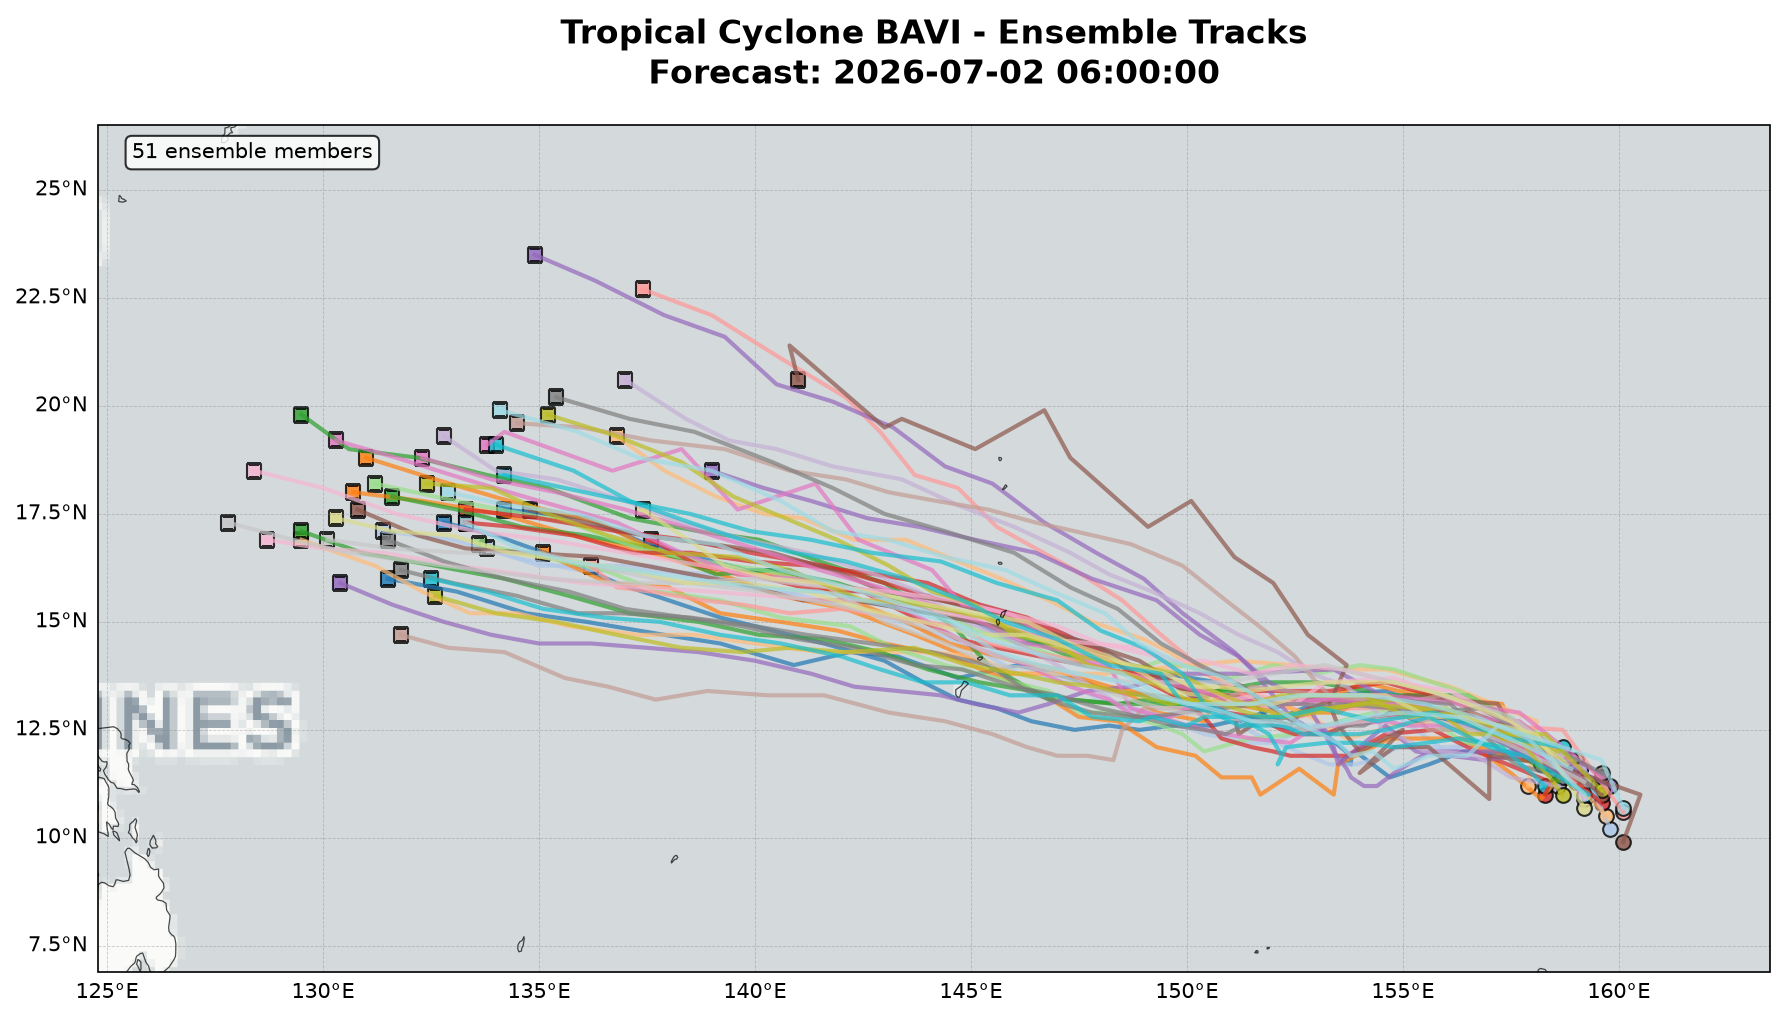

In [14]:
# TC track visualization for the selected storm
show_tracks(str(storm_transformed_file))

TC TRACKS WITH WIND POLYGONS
Loaded 1275 track points from tc_tracks_2026-07-02_r06_storm_BAVI_extracted_transformed.csv
Storm: BAVI
Forecast: 2026-07-02 06:00:00
Showing 3 members
Wind polygon columns: ['wind_field_polygon_34kt', 'wind_field_polygon_50kt', 'wind_field_polygon_64kt']
Available wind thresholds: [34, 50, 64]


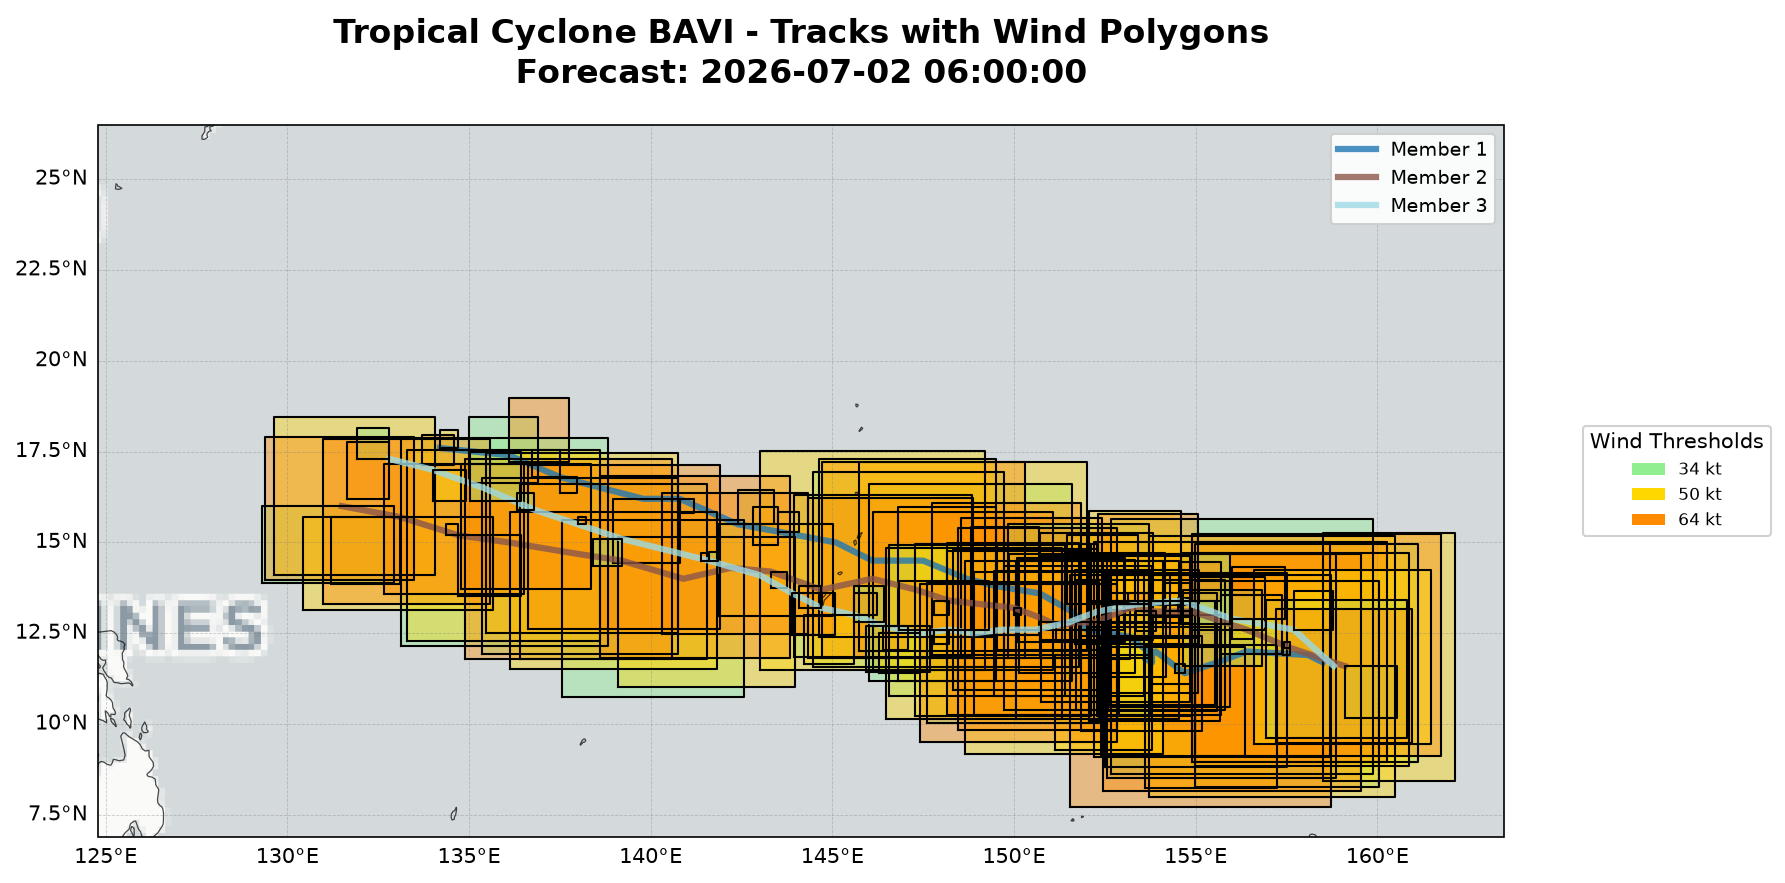

In [15]:
# TC tracks with wind field polygons for the selected storm
show_tracks_with_polygons(str(storm_transformed_file))

INDIVIDUAL WIND ENVELOPES
Loaded 4927 records from BAVI_20260702T06Z_envelopes_individual.csv
Found 4927 records with polygons
Storm: BAVI
Forecast: 2026-07-02 06:00:00
Member: 1
Forecast steps: 6


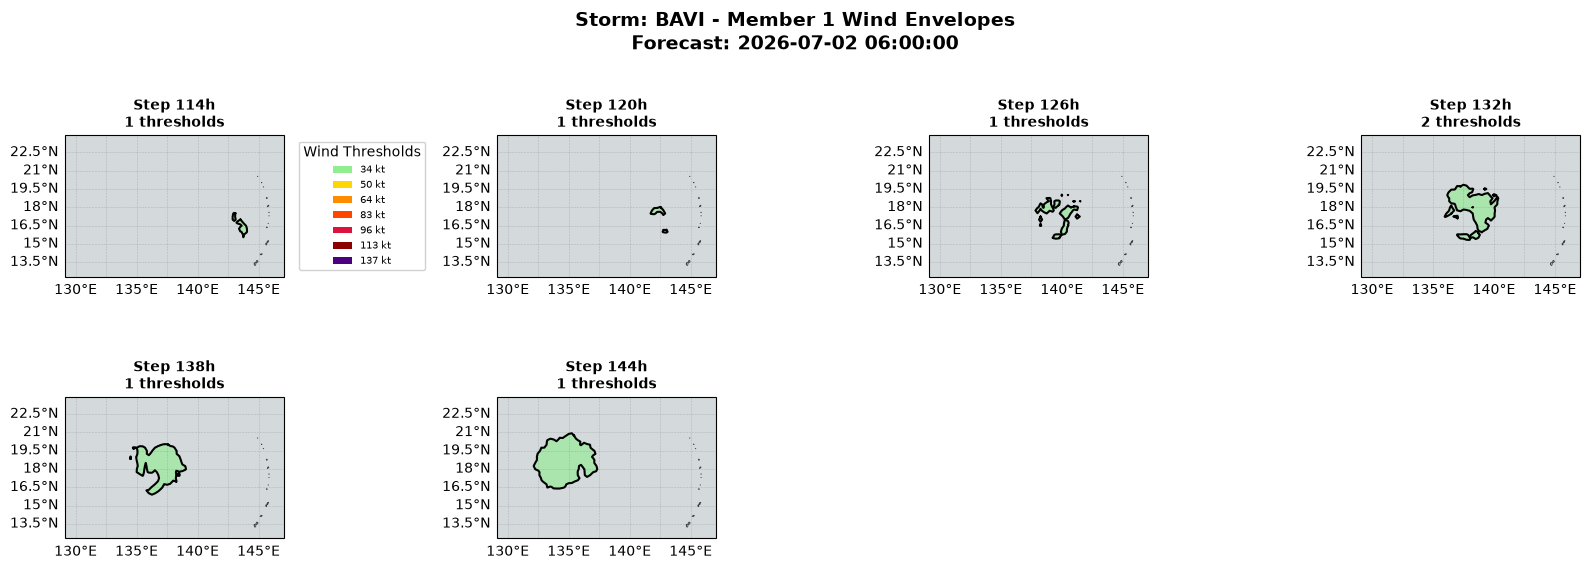

In [16]:
# Individual wind envelopes for the selected storm
show_individual_envelopes(str(storm_individual_file))

COMBINED WIND ENVELOPES
Loaded 325 records from BAVI_20260702T06Z_envelopes_combined.csv
Found 325 records with polygons
Storm: BAVI
Forecast: 2026-07-02 06:00:00
Showing 3 members


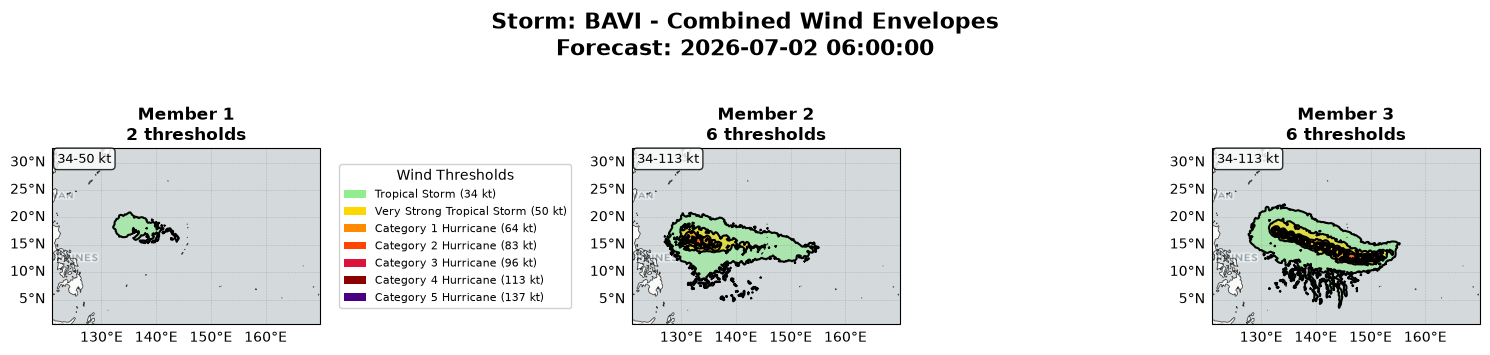

In [17]:
# Combined wind envelopes for the selected storm
show_combined_envelopes(str(storm_combined_file))

## Gust Results

In [18]:
gust_envelope_files = list(_storm_env_dir.glob("*gust*.csv"))

print(f"Gust Envelopes: {len(gust_envelope_files)} file(s)")
for f in gust_envelope_files:
    df_preview = pd.read_csv(f)
    print(f"  - {f.name}  ({len(df_preview)} rows, columns: {list(df_preview.columns)})")

storm_gust_individual_file = next((f for f in gust_envelope_files if 'individual' in f.name), None)
storm_gust_combined_file   = next((f for f in gust_envelope_files if 'combined'   in f.name), None)

print(f"\nGust individual file: {storm_gust_individual_file.name if storm_gust_individual_file else 'NOT FOUND'}")
print(f"Gust combined file:   {storm_gust_combined_file.name   if storm_gust_combined_file   else 'NOT FOUND'}")

Gust Envelopes: 2 file(s)
  - BAVI_20260702T06Z_gust_envelopes_individual.csv  (7211 rows, columns: ['forecast_time', 'track_id', 'ensemble_member', 'valid_time', 'lead_time', 'gust_threshold', 'envelope_region'])
  - BAVI_20260702T06Z_gust_envelopes_combined.csv  (391 rows, columns: ['forecast_time', 'track_id', 'ensemble_member', 'lead_time', 'gust_threshold', 'envelope_region'])

Gust individual file: BAVI_20260702T06Z_gust_envelopes_individual.csv
Gust combined file:   BAVI_20260702T06Z_gust_envelopes_combined.csv


INDIVIDUAL GUST ENVELOPES
Loaded 7211 records from BAVI_20260702T06Z_gust_envelopes_individual.csv
Found 7211 records with polygons
Storm: BAVI
Forecast: 2026-07-02 06:00:00
Member: 1
Forecast steps: 24


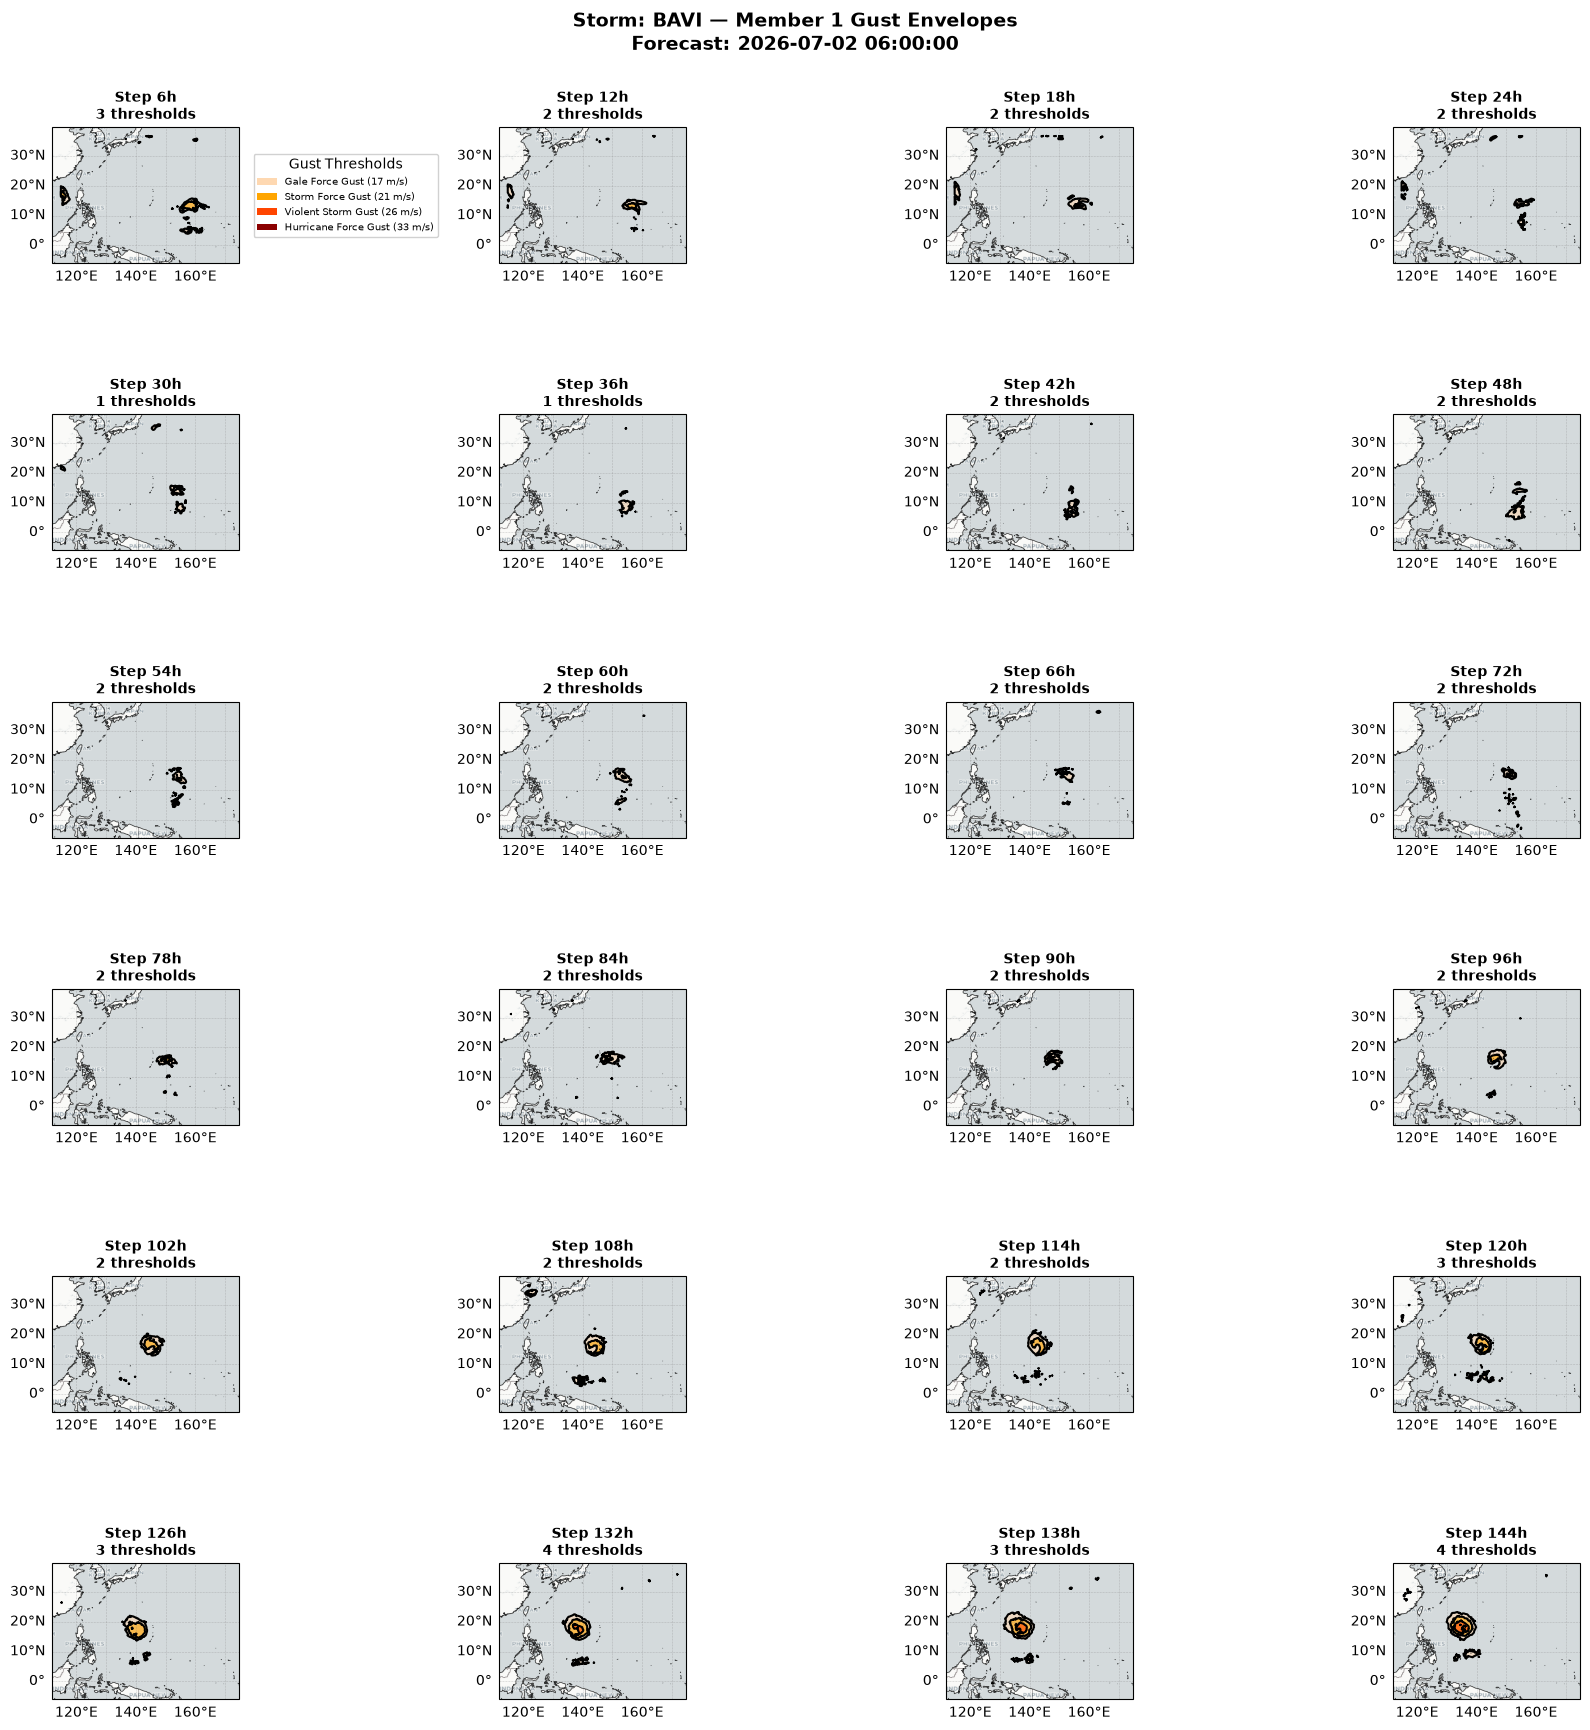

In [19]:
# Individual gust envelopes per forecast step for member 1
show_gust_individual(str(storm_gust_individual_file))

COMBINED GUST ENVELOPES
Loaded 391 records from BAVI_20260702T06Z_gust_envelopes_combined.csv
Found 391 records with polygons
Storm: BAVI
Forecast: 2026-07-02 06:00:00
Showing 3 members


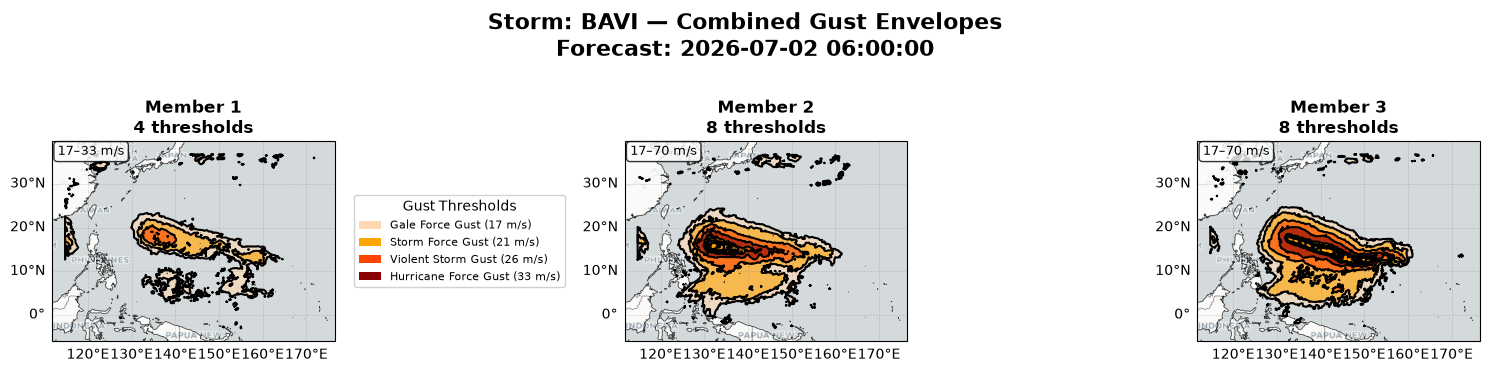

In [20]:
# Combined gust envelopes for the selected storm (unioned across all forecast steps)
show_gust_combined(str(storm_gust_combined_file))

In [ ]:
# Wind vs Gust comparison: auto-selects the member with the most
# wind polygon steps and shows the latest steps where both datasets overlap.
_dw = pd.read_csv(str(storm_individual_file))
_dg = pd.read_csv(str(storm_gust_individual_file))

# Member with most 34kt wind steps that also has 17 m/s gust data
_wind_counts = _dw[_dw.wind_threshold == 34].groupby('ensemble_member')['lead_time'].nunique()
_gust_members = set(_dg[_dg.gust_threshold == 17]['ensemble_member'].unique())
_candidates = _wind_counts[_wind_counts.index.isin(_gust_members)]
_best_member = int(_candidates.idxmax()) if len(_candidates) > 0 else 1

# Steps where both wind and gust have polygons for that member
_w_steps = set(_dw[(_dw.ensemble_member == _best_member) & (_dw.wind_threshold == 34) & _dw.envelope_region.notna()]['lead_time'])
_g_steps = set(_dg[(_dg.ensemble_member == _best_member) & (_dg.gust_threshold == 17) & _dg.envelope_region.notna()]['lead_time'])
_both_steps = sorted(_w_steps & _g_steps)
_show_steps = _both_steps[-8:] if len(_both_steps) > 8 else _both_steps

print(f"Comparison -- member: {_best_member}, steps: {_show_steps}")
show_wind_vs_gust_comparison(
    str(storm_individual_file),
    str(storm_gust_individual_file),
    member=_best_member,
    steps=_show_steps,
)
